## Digital Off-Axis Holography

This notebook covering off-axis holography sits between the previous notebooks and the upcoming phase-retrieval notebooks:

$$
\text{complex field } U(x,y)
\quad\longrightarrow\quad
\text{intensity-only hologram } I(x,y)
\quad\longrightarrow\quad
\text{recovered complex field } U_\text{recon}(x,y).
$$


- In the propagation notebooks, we assumed we already know the complex field.
- In real cameras, we usually measure only intensity.
- Holography solves this by mixing the unknown field with a known reference wave.
- Phase retrieval solves a harder problem: recovering phase without a known reference wave.


### Big picture

A camera measures intensity:

$$
I(x,y)=|E(x,y)|^2.
$$

If the unknown complex field is simply $U(x,y)$, then the camera gives

$$
I(x,y)=|U(x,y)|^2,
$$

which loses the phase of $U$. That is the phase-retrieval problem.

Holography adds a **known reference wave** $R(x,y)$ before the camera:

$$
I(x,y)=|U(x,y)+R(x,y)|^2.
$$

Expanding:

$$
I = |U|^2 + |R|^2 + U R^* + U^*R.
$$

The key terms are the cross-terms:

$$
UR^*, \qquad U^*R.
$$

These contain the unknown complex field $U$, not only its magnitude.

In **off-axis holography**, the reference wave is tilted:

$$
R(x,y)=e^{ik_r x}.
$$

Because of this tilt, the cross-terms are shifted away from the origin in Fourier space. If the tilt is large enough, we can isolate one sideband, shift/remove the known reference phase, and recover $U(x,y)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Fourier functions

In [2]:
def F2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u)))

def iF2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(u)))

### Define a synthetic complex object

We will create a complex object with both amplitude and phase structure.

$$
U(x,y) = A(x,y)e^{i\phi(x,y)}.
$$

The amplitude $A(x,y)$ tells us how strongly the object transmits light.  
The phase $\phi(x,y)$ tells us how much phase delay the object introduces.

Transparent samples can have almost constant amplitude but strong phase contrast. This is why phase imaging is important.

In this synthetic example, the object is not meant to be a physically exact sample. It is a deliberately rich test field that contains:

- a finite square support;
- phase steps;
- circular phase features;
- amplitude variations caused by adding several complex fields.

This makes it useful for checking whether holographic reconstruction recovers both amplitude and phase.


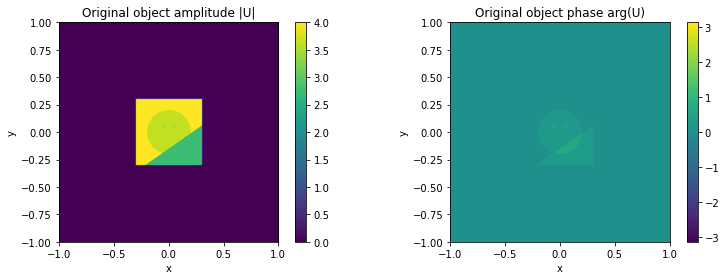

In [3]:

# Number of pixels in each dimension.
N = 512

x = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, x, indexing="xy")

# Define transmitted field U.
U = np.exp(1j * 2 * ((0.7 * X - Y) > 0.15))
U = U + np.exp(1j * ((X**2 + Y**2) < 0.04))
U = U + np.exp(1j * (np.sqrt((X - 0.05)**2 + (Y - 0.05)**2) < 0.02))
U = U + np.exp(1j * (np.sqrt((X + 0.05)**2 + (Y - 0.05)**2) < 0.02))

# Apply finite square support.
support = (np.abs(X) < 0.3) * (np.abs(Y) < 0.3)
U = support * U

# Plot object amplitude and phase.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im0 = axes[0].imshow(np.abs(U), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0].set_title("Original object amplitude |U|")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.angle(U), extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1].set_title("Original object phase arg(U)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()


The left plot is the amplitude:

$$
|U(x,y)|.
$$

The right plot is the phase:

$$
\arg(U(x,y)).
$$

The square support is important because many phase-retrieval algorithms use support constraints. But in this holography notebook, we do **not** need an iterative support constraint because the reference wave helps us directly encode phase information into the intensity measurement.

This is the central difference:

- **Holography:** phase information is encoded by interference with a known reference.
- **CDI / ER / HIO:** no reference wave, so phase must be recovered using constraints.
- **Ptychography:** no explicit reference wave, but we create overlapping measurements.

###  Adding an off-axis reference wave and record intensity

Now we create a tilted reference wave:

$$
R(x,y)=e^{i k_r x}.
$$

The measured hologram is:

$$
I(x,y)=|U(x,y)+R(x,y)|^2.
$$

Expanding:

$$
I = |U|^2 + |R|^2 + U R^* + U^*R.
$$

The two cross-terms carry the complex object field. Because $R$ is tilted, those cross-terms become shifted sidebands in Fourier space.

The tilt $k_r$ is therefore not random. It is chosen to separate the sidebands from the central band.

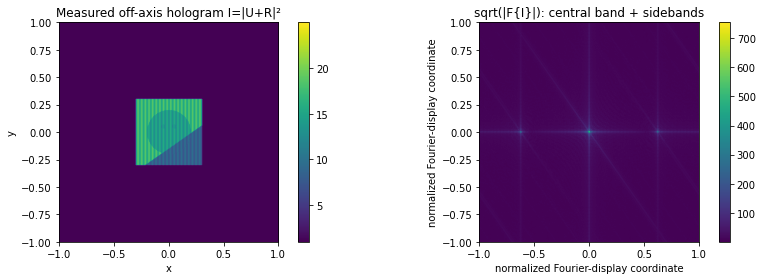

In [15]:

# Reference wave tilt.
# This is a dimensionless value because x is a normalized coordinate from -1 to 1.
# In a physical setup, this would be related to the reference beam angle.
k_ref = 500

ReferenceWave = np.exp(1j * k_ref * X)

# Camera measurement: intensity only.
I = np.abs(U + ReferenceWave)**2

# Fourier transform of the hologram.
FI = F2d(I)

# For display, we use abs(FI)**0.5.
FI_display = np.abs(FI)**0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(I, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0].set_title("Measured off-axis hologram I=|U+R|²")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(FI_display, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[1].set_title("sqrt(|F{I}|): central band + sidebands")
axes[1].set_xlabel("normalized Fourier-display coordinate")
axes[1].set_ylabel("normalized Fourier-display coordinate")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()


### Fourier-domain interpretation

The Fourier transform of the hologram contains three main components:

$$
I = |U|^2 + 1 + U e^{-ik_r x} + U^* e^{ik_r x}.
$$

In Fourier space:

1. $ |U|^2 + 1 $ gives a **central band**.
2. $ U e^{-ik_r x} $ gives one shifted **image sideband**.
3. $ U^* e^{ik_r x} $ gives the shifted **twin-image sideband**.

If the reference tilt is large enough, the sidebands are separated.

Then reconstruction is simple:

1. Fourier transform the hologram.
2. Isolate one sideband.
3. Inverse Fourier transform.
4. Remove the known reference-wave phase.

This is why off-axis holography is powerful: it turns phase recovery into Fourier filtering.


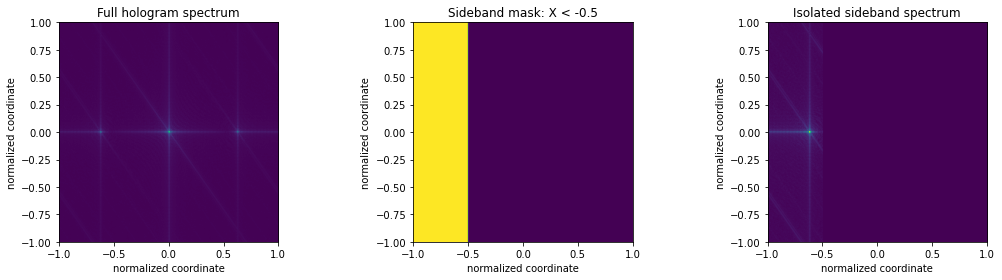

In [16]:

# Simple sideband mask
# It is a simple half-plane mask that selects the left sideband.
sideband_mask = (X < -0.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(FI_display, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0].set_title("Full hologram spectrum")
axes[0].set_xlabel("normalized coordinate")
axes[0].set_ylabel("normalized coordinate")

axes[1].imshow(sideband_mask, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[1].set_title("Sideband mask: X < -0.5")
axes[1].set_xlabel("normalized coordinate")
axes[1].set_ylabel("normalized coordinate")

axes[2].imshow(FI_display * sideband_mask, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[2].set_title("Isolated sideband spectrum")
axes[2].set_xlabel("normalized coordinate")
axes[2].set_ylabel("normalized coordinate")

plt.tight_layout()
plt.show()


#### Important limitation of this simple mask

The mask

\[
X < -0.5
\]

is not a carefully optimized physical filter. It is a simple pedagogical mask.

It works because the reference tilt is large enough that the sideband is visibly separated from the central band.

In a real digital holography implementation, one would usually:

- estimate the sideband center;
- use a circular/elliptical window around the sideband;
- etc.

Here we keep the simple mask that demonstrates the principle very clearly.


### Reconstruct the object field

The isolated sideband corresponds to:

$$
U(x,y)e^{-ik_r x}.
$$

After inverse Fourier transforming the sideband, the reconstruction still contains the carrier phase $e^{-ik_r x}$. Multiplying by

$$
R(x,y)=e^{ik_r x}
$$

removes this carrier:

$$
U(x,y)e^{-ik_r x} \cdot e^{ik_r x} = U(x,y).
$$


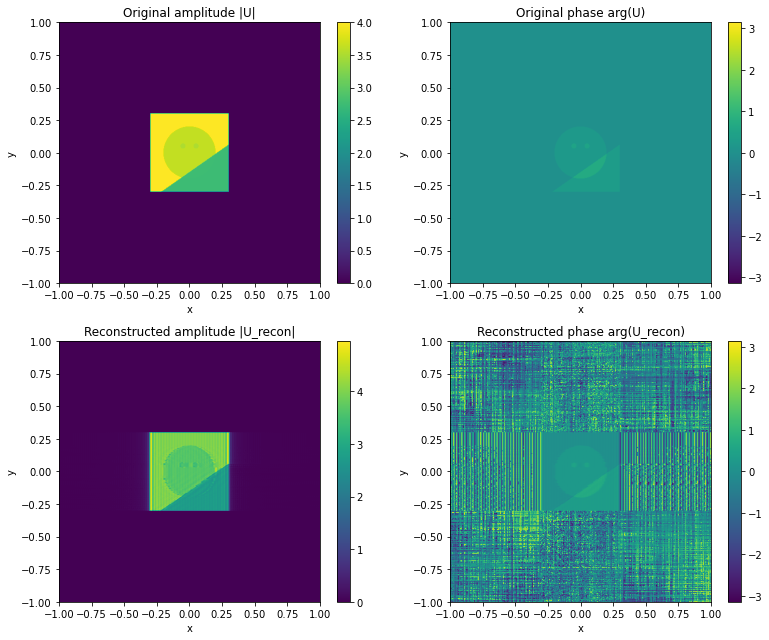

In [17]:

# Reconstruct object:
# 1. Fourier transform intensity.
# 2. Isolate one sideband.
# 3. Inverse Fourier transform.
# 4. Remove reference carrier phase.
U_recon = iF2d(FI * sideband_mask) * ReferenceWave

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

im00 = axes[0, 0].imshow(np.abs(U), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0, 0].set_title("Original amplitude |U|")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046)

im01 = axes[0, 1].imshow(np.angle(U), extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title("Original phase arg(U)")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046)

im10 = axes[1, 0].imshow(np.abs(U_recon), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[1, 0].set_title("Reconstructed amplitude |U_recon|")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046)

im11 = axes[1, 1].imshow(np.angle(U_recon), extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title("Reconstructed phase arg(U_recon)")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("y")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()


#### Interpreting the reconstruction

The reconstruction should recover the main amplitude and phase features of the original object.

It is not perfect. The most important reason is that the sideband filtering clips part of the object's spectrum. When we multiply the Fourier spectrum by a hard mask, we are throwing away some spatial frequencies.

This means:

- sharp edges blur;
- fine details get lost;
- amplitude/phase may show artifacts near support boundaries.

This is not a failure of the principle. It is the price of simple Fourier filtering.


### What happens if the reference tilt is too small?

The off-axis method depends on sideband separation.

If the reference tilt $k_r$ is too small, the central band and sidebands overlap in Fourier space. Then you cannot cleanly isolate $U$, and reconstruction becomes contaminated by:

- the central intensity term $1+|U|^2$;
- the twin image $U^*$;

This is the practical design rule:

> Larger reference tilt improves sideband separation, but if the tilt is too large, fringes may exceed the camera sampling limit and alias.

So there is a tradeoff:

$$
\text{too small tilt} \Rightarrow \text{sideband overlap}
$$

$$
\text{too large tilt} \Rightarrow \text{undersampled fringes / aliasing}.
$$

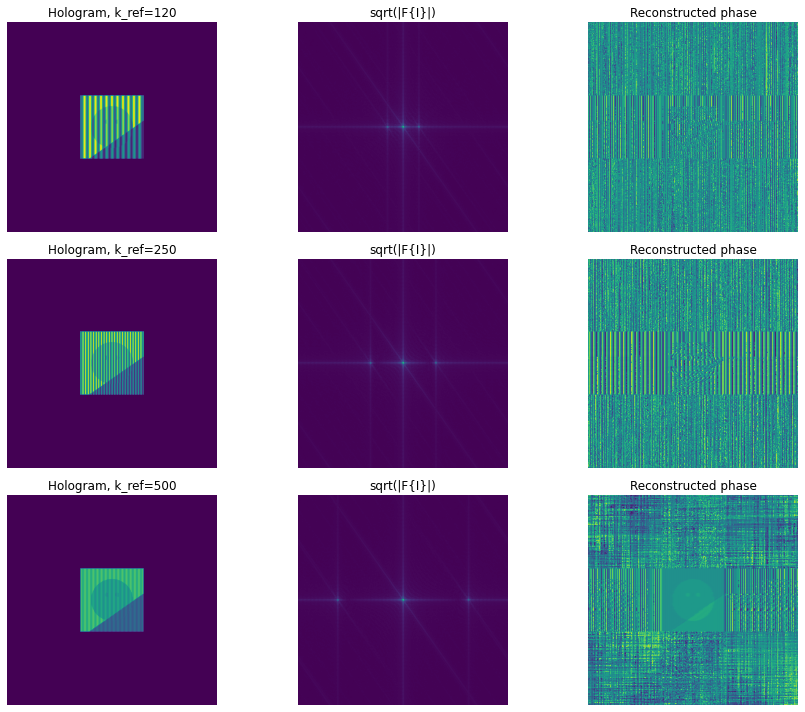

In [18]:

def holography_reconstruct_with_tilt(k_ref_value, mask_threshold=-0.5):
    """
    Create hologram and reconstruct using the same simple half-plane mask.

    This is used to compare how reference tilt affects sideband separation.
    """
    R = np.exp(1j * k_ref_value * X)
    I_local = np.abs(U + R)**2
    FI_local = F2d(I_local)
    mask = X < mask_threshold
    U_rec_local = iF2d(FI_local * mask) * R
    return I_local, FI_local, U_rec_local


tilts = [120, 250, 500]

fig, axes = plt.subplots(len(tilts), 3, figsize=(13, 10))

for row, k_val in enumerate(tilts):
    I_local, FI_local, U_rec_local = holography_reconstruct_with_tilt(k_val)

    axes[row, 0].imshow(I_local, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
    axes[row, 0].set_title(f"Hologram, k_ref={k_val}")
    axes[row, 0].set_axis_off()

    axes[row, 1].imshow(np.abs(FI_local)**0.5, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
    axes[row, 1].set_title("sqrt(|F{I}|)")
    axes[row, 1].set_axis_off()

    axes[row, 2].imshow(np.angle(U_rec_local), extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
    axes[row, 2].set_title("Reconstructed phase")
    axes[row, 2].set_axis_off()

plt.tight_layout()
plt.show()


As the reference tilt increases:

- the fringes in the hologram become denser;
- the sidebands move farther from the central band in Fourier space;
- sideband isolation becomes easier;
- reconstruction quality generally improves until sampling becomes a problem.
